# PARTE 5 - Inference and Validation (Objetos Peligrosos)

En esta parte se valida el modelo CNN entrenado en la Parte 4 utilizando imágenes no vistas para evaluar su capacidad de generalización.

## 1. Importar librerías
Se importan las librerías necesarias para cargar el modelo, procesar el dataset y realizar la inferencia.

In [8]:
import torch
import torch.nn as nn

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

## 2. Configurar el dispositivo
Se verifica si hay una GPU disponible para acelerar la ejecución del modelo. Si no hay una, se utiliza la CPU.

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Dispositivo:", device)

Dispositivo: cpu


## 3. Preparar el dataset
Se carga el mismo dataset utilizando el mismo preprocesamiento que se aplicó durante el entrenamiento.

In [10]:
transform = transforms.Compose([

    transforms.Resize((64,64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),
                         (0.5,0.5,0.5))
])

dataset = datasets.ImageFolder(

    root="../data/class",
    transform=transform
)

test_loader = DataLoader(

    dataset,
    batch_size=32,
    shuffle=False
)

classes = dataset.classes

print(classes)

['alcohol', 'blood', 'cigarette', 'gun', 'insulting_gesture', 'knife']


## 4. Definir la arquitectura CNN
Se crea nuevamente la arquitectura de la red para poder cargar el modelo entrenado.

In [11]:
class DangerousObjectCNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.conv_layers = nn.Sequential(

            nn.Conv2d(3,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc_layers = nn.Sequential(

            nn.Flatten(),

            nn.Linear(64*16*16,128),
            nn.ReLU(),

            nn.Linear(128,6)
        )

    def forward(self,x):

        x=self.conv_layers(x)
        x=self.fc_layers(x)

        return x

## 5. Cargar el modelo entrenado
Se cargan los pesos guardados del modelo para utilizarlo en la validación y la inferencia.

In [12]:
model = DangerousObjectCNN().to(device)

model.load_state_dict(

    torch.load(
        "dangerous_objects_cnn.pth",
        map_location=device
    )
)

model.eval()

print("Modelo cargado correctamente")

Modelo cargado correctamente


## 6. Función de validación
Se crea una función que calcula la pérdida y la precisión del modelo sobre el conjunto de validación.


In [13]:
criterion = nn.CrossEntropyLoss()

def validation(model, loader):

    total_loss = 0

    correct = 0

    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            total_loss += loss.item()

            _, predicted = torch.max(outputs,1)

            total += labels.size(0)

            correct += (predicted==labels).sum().item()

    accuracy = 100*correct/total

    avg_loss = total_loss/len(loader)

    return avg_loss, accuracy

## 7. Ejecutar la validación
Se evalúa el modelo con imágenes que no participaron en el entrenamiento.


In [14]:
loss, accuracy = validation(

    model,
    test_loader
)

print(f"Loss: {loss:.4f}")
print(f"Accuracy: {accuracy:.2f}%")

Loss: 0.9426
Accuracy: 66.01%


## 8. Realizar la inferencia
Se realizan predicciones sobre nuevas imágenes del dataset.

In [15]:
images, labels = next(iter(test_loader))

image = images[0].unsqueeze(0).to(device)

model.eval()

with torch.no_grad():

    outputs = model(image)

    _, prediction = torch.max(outputs,1)

## 9. Mostrar los resultados
Se visualizan algunas imágenes junto con su clase real y la predicción realizada por el modelo.

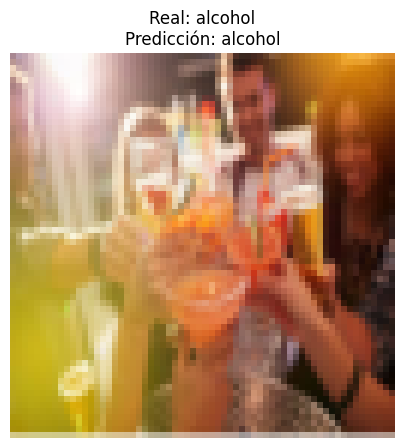

In [16]:
img = images[0].permute(1,2,0).numpy()

img = (img*0.5)+0.5

img = img.clip(0,1)

plt.figure(figsize=(5,5))

plt.imshow(img)

plt.title(

    f"Real: {classes[labels[0]]}\n"
    f"Predicción: {classes[prediction.item()]}"
)

plt.axis("off")

plt.show()

## 10. Analizar los resultados
Se revisan las métricas obtenidas y se observan los aciertos y los errores del modelo.

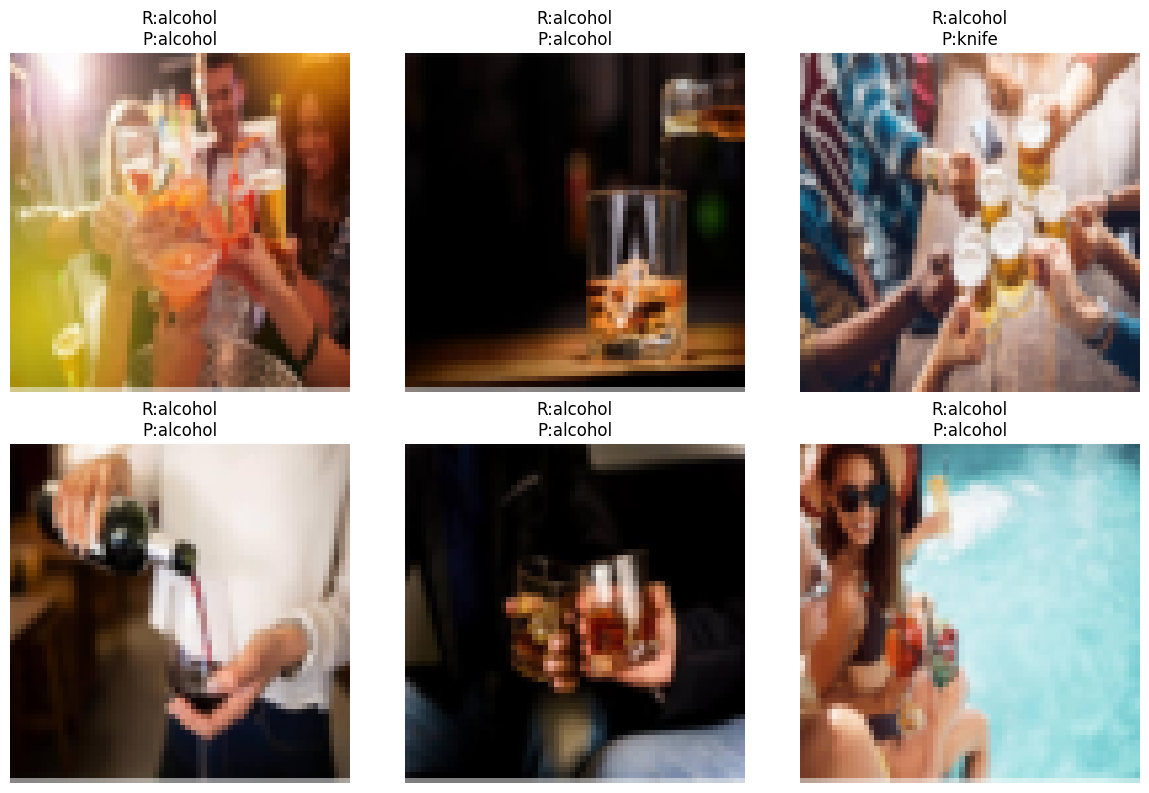

In [17]:
model.eval()

fig, axes = plt.subplots(2,3,figsize=(12,8))

axes = axes.flatten()

count = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs,1)

        for i in range(images.size(0)):

            img = images[i].cpu().permute(1,2,0).numpy()

            img = (img*0.5)+0.5

            img = img.clip(0,1)

            axes[count].imshow(img)

            axes[count].set_title(

                f"R:{classes[labels[i]]}\nP:{classes[predicted[i]]}"
            )

            axes[count].axis("off")

            count += 1

            if count == 6:
                break

        if count == 6:
            break

plt.tight_layout()

plt.show()